# project overview

## pinnacle Meta Ads compaign Dataset insights eda

This project focuses on data cleaning, transformation, and structuring of a  Meta Ads dataset contains 238 rows and 644 columns

This data need  preprocessing before analysis due to high dimensionality, semi structured formats and inconsistencies columns like so many not important columns. The main goal of cleaning data in excel sheet was to prepare the dataset for analysis in Python,

so i did initial Exploratory Data Analysis (EDA) in excel :
and created modified new columns such as

Engagement Rate

Conversion Rate

Performance metrics across daily, monthly,hourly


Excel Cleanup & Data Preparation Summary : -

* Removed Unnecessary JSON Columns : The dataset included columns with nested JSON content. Since important values were already extracted into separate columns so the raw JSON columns were deleted to simplify the dataset. But
"i felt json data extraction at initial step can maintain rich data i know basic of json format and how can we extract data if i will get a chance then by researching more i can try to extract data in peeticular orders for analysis and can collect clean data by handeling nested lists"


* Created Platform Column(Facebook,Instagram,Thread) : Platform information was derived from JSON. However due to inaccuracy the final values were generated using randomization techniques to maintain structure for analysis.


* Standardized Gender Column : The gender column initially has only female(109/237). To balance the data for testing and analysis, all values (which was instead of male female) were replaced with “male” to maintain structure for analysis.


* Removed High Null/nan Columns : Any column with 80–90% null values was dropped, as they added little to no analytical value and cluttered the dataset.

* nan in excel treated as text so if i load all null values will show as text in python can temper data so i leaved blank rows in excel so that it will be treated as nan in python

* Changed Data Types Appropriately : Every column was reviewed and assigned the correct data type such as date, int, float, and bool—to avoid errors during computation in Python.currency,datetime also


* Dropped some less important Columns : Columns **like last 1 hours columns ,1 Hour Impressions, 5K Impressions, 10K Impressions,age based column like 35 age .44 age , day wise multiple columns like monday tuesday etc all week days(because it can be done in python with help of date time) related column can be done in python by head too i easy way etc.**, were removed. These were unreliable and could be recalculated using daily impression data later. if we will have accurate data time exact time span and date day wise impression these can be calucalted easily according to need and for now our target is basic analysis so i removed these column to make our data much efficient.
* **reason to remove : -** reson to remove was all of these column make data so bulky and less efficient during eda it can be very time taking and confusing to instead the same calculation we can do temporarily by python pandas and matplotlib, numpy etc libraries.

* Deleted Weekday-Specific Columns : Columns indicating performance on specific days (e.g., Thursday, Friday, Saturday) were dropped due to their redundancy in this phase of analysis.because these can also be extracted and can be visualised by accurate calender data.


* Ensured Unique Ad IDs: Ad ID uniqueness was enforced to assist in indexing and grouping data reliably.


* Removed Derivable Columns : Columns like Ad Rank, Average CPC (Top 25%), etc., were dropped since they can be calculated later during Python analysis using aggregations or ranking methods.


* Handled NaN Values: Excel columns with NaN (not a number) were visually blank but caused reading issues in Python. These were either filled or cleaned to ensure smooth parsing.it was important too because after extracting data nan was treadted like text by excel and if i have to upload it in python python needs to re-difine nan as Nan else python will recognise it as text nan.



Created New Metric Columns  : Custom metric columns such as:

* Engagement Rate(for last 24 hour ,last 7 days,for general data)

* Conversion Rate (for last 24 hour ,last 7 days,for general data)

* were created for daily, weekly, and total-level analysis.

*  Added Time-Based Columns :  Date Range was created using ad start and end dates.

A Month column was generated to allow monthly trend analysis.




## Next Steps: Python-Based Analysis

With the cleaned dataset not properly but 70% + approximate, the next phase involves:

* Loading data into Python

* Handling any remaining nulls, anomalies,  duplicates etc

* Counting unique values, validating distributions

* Performing Exploratory Data Analysis (EDA) using visualization and summary statistics

* Generating final performance metrics

# importing the Meta ads dataset and Related Libraries

In [64]:
# Import Libraries
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data = pd.read_excel('meta_ads_with_json_dataset_sample.xlsx')


# Data View and Understanding

In [66]:
# Dataset First Look(first 5 column by default)
data.head()

# remark :- in excel as we tackled the null/nan values they were their treating
# as text and if i load exact same i have to do alterante detail cleaning again by replacing nan text to pandas NaN

,id,ad_id,ad_name,clean_ad_name,adset_id,adset_name,campaign_id,campaign_name,basis_targeting,basis_objective,...,ad_type,ad_link,Link_Urls,instagram_permalink_url,Reach,Frequency,target_advantage_audience,Bucket,CPLPV,ad_status_of_hourly_table
0,1,120219670519220552,3.5_A | Join Waitlist,a | join waitlist,120219670519190552,3.5 | Interest | Entrepreneurship | Insta,120219670519270552,Web App | Conversion | StepOut | Delhi | Farid...,Broad Prospecting,Leads,...,SHARE,https://external.fdel27-3.fna.fbcdn.net/emg1/v...,NaN,https://www.instagram.com/p/DHnvDyWgvRu/,343600,0.00,0.0,Broad Prospecting_Leads,76.7900,PAUSED
1,2,120219670933900552,3.1_A | Join Waitlist,a | join waitlist,120219670519230552,"3.1 | Interest | Food, Dinner (Mid + High Valu...",120219670519270552,Web App | Conversion | StepOut | Delhi | Farid...,Broad Prospecting,Leads,...,SHARE,https://external.fdel27-3.fna.fbcdn.net/emg1/v...,NaN,https://www.instagram.com/p/DILdW9JtreX/,41900,0.04,0.0,Broad Prospecting_Leads,117.3880,PAUSED
2,3,120219670936520552,3.4_A | Join Waitlist,a | join waitlist,120219670519240552,3.4 | Interest | Event ( Mid + High Value Wort...,120219670519270552,Web App | Conversion | StepOut | Delhi | Farid...,Broad Prospecting,Leads,...,SHARE,https://external.fdel27-3.fna.fbcdn.net/emg1/v...,NaN,https://www.instagram.com/p/DHnvDkJgmsH/,1100,0.63,0.0,Broad Prospecting_Leads,81.2767,PAUSED
3,4,120219670938510552,3.3_A | Join Waitlist,a | join waitlist,120219670519250552,3.3 | Interest | Travel | Insta,120219670519270552,Web App | Conversion | StepOut | Delhi | Farid...,Broad Prospecting,Leads,...,SHARE,https://external.fdel27-3.fna.fbcdn.net/emg1/v...,[],https://www.instagram.com/p/DJ1UYNNArJh/,450400,0.00,0.0,Broad Prospecting_Leads,76.1333,PAUSED
4,5,120219670941240552,3.2_A | Join Waitlist,a | join waitlist,120219670519260552,3.2 | Interest | Socializing | Insta,120219670519270552,Web App | Conversion | StepOut | Delhi | Farid...,Broad Prospecting,Leads,...,SHARE,https://external.fdel27-3.fna.fbcdn.net/emg1/v...,NaN,https://www.instagram.com/p/DHnvDjVAjRU/,147800,0.00,0.0,Broad Prospecting_Leads,175.8800,PAUSED


In [67]:
# data set Last 5 rows data
data.tail()

,id,ad_id,ad_name,clean_ad_name,adset_id,adset_name,campaign_id,campaign_name,basis_targeting,basis_objective,...,ad_type,ad_link,Link_Urls,instagram_permalink_url,Reach,Frequency,target_advantage_audience,Bucket,CPLPV,ad_status_of_hourly_table
232,613,120228369143270552,Saturday Night,saturday night,120223643161880552,Women - Clubbed Audience + Mid & High Value Worth,120223643161560552,VM || Delhi NCR || Traffic || 16-05-2025,Broad Prospecting,Clicks,...,SHARE,https://scontent.fdel27-1.fna.fbcdn.net/v/t15....,[{'url': 'https://www.stepout.world/?utm_sourc...,https://www.instagram.com/p/DLVVf4-AaA-/,10700000,0.03,0.0,Broad Prospecting_Clicks,1.2982,ACTIVE
233,615,120228369494730552,5 Strangers - Ver 1,5 strangers - ver 1,120223643161880552,Women - Clubbed Audience + Mid & High Value Worth,120223643161560552,VM || Delhi NCR || Traffic || 16-05-2025,Broad Prospecting,Clicks,...,SHARE,https://scontent.fdel27-7.fna.fbcdn.net/v/t45....,"[{'url': 'https://www.stepout.world/', 'adlabe...",https://www.instagram.com/p/DLVVgstApq2/,10700000,0.00,0.0,Broad Prospecting_Clicks,1.6202,ACTIVE
234,629,120228514646190552,Lunch Launch - Bright - Ver 3,lunch launch - bright - ver 3,120223643161880552,Women - Clubbed Audience + Mid & High Value Worth,120223643161560552,VM || Delhi NCR || Traffic || 16-05-2025,Broad Prospecting,Clicks,...,SHARE,https://scontent.fdel27-1.fna.fbcdn.net/v/t45....,[{'url': 'https://www.stepout.world/?utm_sourc...,https://www.instagram.com/p/DLVVh1Ggnk9/,10700000,0.00,0.0,Broad Prospecting_Clicks,1.7342,ACTIVE
235,634,120228524233220552,Lunch Launch - Bright - Ver 5,lunch launch - bright - ver 5,120223643161880552,Women - Clubbed Audience + Mid & High Value Worth,120223643161560552,VM || Delhi NCR || Traffic || 16-05-2025,Broad Prospecting,Clicks,...,SHARE,https://scontent.fdel27-1.fna.fbcdn.net/v/t45....,[{'url': 'https://www.stepout.world/?utm_sourc...,https://www.instagram.com/p/DLVVikzAC0m/,10700000,0.00,0.0,Broad Prospecting_Clicks,1.2472,ACTIVE
236,641,120228638978370552,Ranveer,ranveer,120223643161880552,Women - Clubbed Audience + Mid & High Value Worth,120223643161560552,VM || Delhi NCR || Traffic || 16-05-2025,Broad Prospecting,Clicks,...,VIDEO,https://scontent.fdel52-1.fna.fbcdn.net/v/t15....,[],https://www.instagram.com/p/DLZsH85gxQD/,10700000,0.02,0.0,Broad Prospecting_Clicks,1.2383,ACTIVE


# shape of dataset

In [68]:
# Dataset Rows and Columns count
data.shape

# we reduced our 644 cokumns into 72 columns and thier is not such any big data loss because we can calculate after analysis
# whatever related or some columns were not giving any data just taking memory so we dropped them

(237, 644)

# Dataset Information

In [69]:
# Dataset Info
data.info()

# so many column mostly the columns which is related to 24 hour and 7 days has many null values but
# we will use more the rich in data column and treat null accoording to our need either 0 or keep it nan or remove null rows
# our calender and budget column showing object we have to keep notice it during analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Columns: 644 entries, id to ad_status_of_hourly_table
dtypes: bool(3), datetime64[ns](3), float64(587), int64(10), object(41)
memory usage: 1.2+ MB


# to_datetime coulmns

In [70]:
# these column were showing in object format and it can be crucial during analysis so changed into date_time
data['ad_start_date'] = pd.to_datetime(data['ad_start_date'], dayfirst=True, errors='coerce')
data['ad_end_date'] = pd.to_datetime(data['ad_end_date'], dayfirst=True, errors='coerce')


In [71]:
#successfully converted
print(data['ad_start_date'].dtype)
print(data['ad_end_date'].dtype)


datetime64[ns]
datetime64[ns]


Duplicate Values

In [72]:
# Dataset Duplicate Value Count
data.duplicated().sum()

# We found no duplicates values as we have all unique ad id

np.int64(0)

Missing Values or Null Values

In [73]:
try:
    # Missing Values/Null Values Count
    data.isnull().sum()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

In [74]:
try:
    # Missing Values/Null Value coumns and count
    data.isnull().sum()[data.isnull().sum() > 0]
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

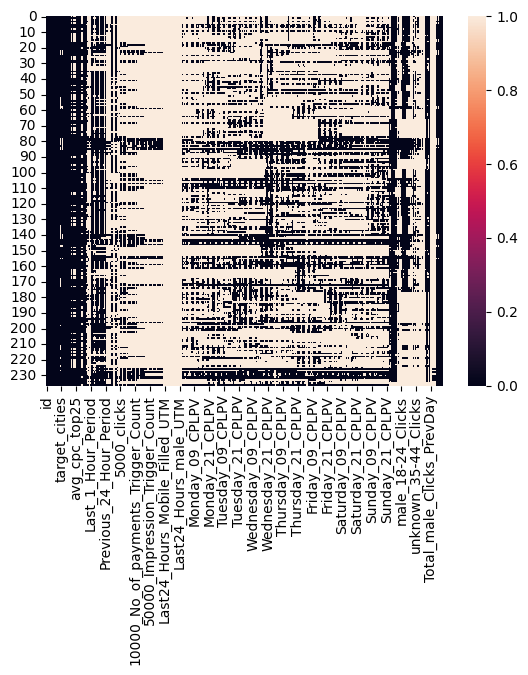

In [75]:
try:
    # Visualizing the missing values
    sns.heatmap(data.isnull())
    #mostly null in last 24 hour and last 7 days
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

In [76]:
# Checking all unique campaign_id
data.campaign_id.unique()


array([120219670519270552, 120217657777920552, 120222626163580552,
       120222690236800552, 120222756890700552, 120222691853650552,
       120222796320450552, 120222866045270552, 120222948161460552,
       120222949776580552, 120222952258010552, 120223050276960552,
       120223143686530552, 120223168688990552, 120223188847160552,
       120223327117000552, 120223580715080552, 120223582797960552,
       120223643161560552, 120223652043790552, 120223742281510552,
       120223996097960552])

In [77]:
# Checking all unique adset_id
data.adset_id.unique()

array([120219670519190552, 120219670519230552, 120219670519240552,
       120219670519250552, 120219670519260552, 120219735487680552,
       120219809715990552, 120220829126660552, 120222189670390552,
       120222626163630552, 120222690236900552, 120222756890750552,
       120222691854000552, 120222796322490552, 120222866046180552,
       120222868318370552, 120222941954000552, 120222942353930552,
       120222948161590552, 120222949776780552, 120222952258420552,
       120223050277140552, 120223143686700552, 120223168689080552,
       120223188847320552, 120223216284180552, 120223220363060552,
       120223220434970552, 120223220473480552, 120223220513430552,
       120223220548000552, 120223220565160552, 120223220591220552,
       120223220631440552, 120223220686940552, 120223327117050552,
       120223580715190552, 120223582798070552, 120223643161880552,
       120223652044480552, 120223655131030552, 120223742281680552,
       120223769076740552, 120223769241210552, 120223769426970

# Understanding OUR Variables & complete Data Set

In [78]:
# understanding our columns
data.columns

Index(['id', 'ad_id', 'ad_name', 'clean_ad_name', 'adset_id', 'adset_name',
       'campaign_id', 'campaign_name', 'basis_targeting', 'basis_objective',
       ...
       'ad_type', 'ad_link', 'Link_Urls', 'instagram_permalink_url', 'Reach',
       'Frequency', 'target_advantage_audience', 'Bucket', 'CPLPV',
       'ad_status_of_hourly_table'],
      dtype='object', length=644)

In [79]:
# Dataset Describe
data.describe()

,id,ad_id,adset_id,campaign_id,ad_start_date,ad_end_date,total_hours,target_age_min,target_age_max,daily_budget,...,Total_female_impressions_PrevDay,Total_female_Clicks_PrevDay,Total_female_Spend_PrevDay,Total_unknown_impressions_PrevDay,Total_unknown_Clicks_PrevDay,Total_unknown_Spend_PrevDay,Reach,Frequency,target_advantage_audience,CPLPV
count,237.000000,2.370000e+02,2.370000e+02,2.370000e+02,237,237,237.000000,237.000000,237.000000,219.000000,...,6.000000,6.000000,6.0000,0.0,6.0,6.0,2.370000e+02,237.000000,236.000000,223.000000
mean,142.109705,1.202234e+17,1.202227e+17,1.202205e+17,2025-04-19 21:11:08.354430464,2025-04-29 15:14:56.202531328,119.050633,23.185654,52.000000,74678.538813,...,13164.833333,393.666667,389.4450,NaN,0.0,0.0,8.502830e+05,-798.771392,0.165254,28.648403
min,1.000000,1.202197e+17,1.202197e+17,1.202177e+17,2025-03-17 18:00:00,2025-03-19 16:00:00,1.000000,18.000000,35.000000,9000.000000,...,144.000000,1.000000,1.4000,NaN,0.0,0.0,-1.000000e+00,-114845.000000,0.000000,1.238300
25%,60.000000,1.202229e+17,1.202229e+17,1.202197e+17,2025-04-10 18:00:00,2025-04-16 18:00:00,37.000000,22.000000,45.000000,50000.000000,...,1692.500000,26.250000,29.7900,NaN,0.0,0.0,4.500000e+03,0.000000,0.000000,10.986950
50%,119.000000,1.202232e+17,1.202232e+17,1.202197e+17,2025-04-16 20:00:00,2025-04-25 10:00:00,75.000000,22.000000,55.000000,80000.000000,...,11844.000000,127.000000,100.7100,NaN,0.0,0.0,4.190000e+04,0.040000,0.000000,17.975000
75%,178.000000,1.202239e+17,1.202238e+17,1.202197e+17,2025-04-25 18:00:00,2025-05-06 22:00:00,133.000000,25.000000,55.000000,100000.000000,...,25072.000000,756.500000,687.6000,NaN,0.0,0.0,2.437000e+05,0.390000,0.000000,29.528000
max,641.000000,1.202286e+17,1.202240e+17,1.202240e+17,2025-06-27 16:00:00,2025-07-16 15:00:00,1096.000000,30.000000,65.000000,175000.000000,...,27367.000000,1148.000000,1244.4700,NaN,0.0,0.0,1.070000e+07,273.560000,1.000000,301.320000
std,125.860818,1.589186e+12,1.439592e+12,1.514176e+12,NaN,NaN,162.728762,3.462775,8.164101,27353.523927,...,12874.542577,512.846436,531.2739,NaN,0.0,0.0,2.626897e+06,7574.164410,0.372199,37.627835


In [80]:
# Check Unique Values for each variable.
pd.set_option('display.max_rows', 100)  # or 200
data.nunique()

,0
id,237
ad_id,237
ad_name,119
clean_ad_name,111
adset_id,50
...,...
Frequency,107
target_advantage_audience,2
Bucket,7
CPLPV,223


# DATA WRANGLING SECTION (IMPROVE COLUMNS AND ROWS QUALITY)

AS we know most of data is balanced now because we did important cleanup in excel too so for now the major issue is nan null we dont need to handle major null values columns becuase if we delete column then it will cause error to us so lets do it by one by one

# lets do it again so that can find out

In [81]:
try:
    # Missing Values/Null Value coumns and count
    data.isnull().sum()[data.isnull().sum() > 0]

    # our objective is to do tackle null values of the column which are essential for our analysis so lets do accordingly
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

here i tackle those missing values which are text format

In [82]:
try:
    # List of columns to update so that can update at once all column as they are unknown
    columns_to_update = ['target_interests', 'Updated_Interest', 'target_behaviors','target_cities','target_regions','bid_strategy',]

    # Replace NaN values with 'Unknown' in the selected columns so that we can know these data not available
    # reason all text based columns
    data[columns_to_update] = data[columns_to_update].fillna('Unknown')
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: "['Updated_Interest'] not in index"


* as i cant delete rows because i have limited rows so if i delete even 20 column it will loss of 10% data approximate so i will try to replace with zero or as 24 hour 7 days not that much essential i will keep nan as it will not affect process

In [83]:
try:
    # Filling missing values with the mean of each column because daily budget should be generalised
    # reason we will get avg daily budget so our data will be more to reality
    data['daily_budget'] = data['daily_budget'].fillna(data['daily_budget'].mean())
    data['composite_score'] = data['composite_score'].fillna(data['composite_score'].mean())

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

* now the last 24 hour and 7 days some column i can replace with 0 because thier is a possibility of 0 impression ,0click,and o hour , 0 spend so the best suitable here will be to replace it with 0 because it wont affect our data

In [84]:
try:
    # Fill zeros for activity columns
    activity_cols = [
        'Last_24_Hour_Impression', 'Last_24_Hour_clicks', 'Last_24_Hour_Spend',
        'Last_24_Hour_landing_page_view', 'Last_24_Hour_No_of_payments', 'Last_24_Hour_UTM_Count',
        'Last_7_Days_Impression', 'Last_7_Days_clicks', 'Last_7_Days_Spend',
        'Last_7_Days_landing_page_view', 'Last_7_Days_No_of_payments', 'Last_7_Days_UTM_Count'
    ]
    data[activity_cols] = data[activity_cols].fillna(0)

    # rest remaining few column i am keeping as it is nan because 80-90% rows are nan
    # so even replacing with 0 can mislead data and they are not such imp for analysis too
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

In [85]:
try:
    # Best practice for pivot-friendly data
    cols_fill_zero = [
        'Engagement_rate_last24hour', 'Last_24_Hour_CPLPV', 'Engagement_rate(last 7days)ctr',
        'Conversion_rate(last_7_days)', 'Last_7_Days_CPLPV'
    ]
    data[cols_fill_zero] = data[cols_fill_zero].fillna(0)

    data['Last_24_Hour_Period'] = data['Last_24_Hour_Period'].fillna('Unknown')
    data['Last_7_Days_Period'] = data['Last_7_Days_Period'].fillna('Unknown')

    data['CPLPV_overall'] = data['CPLPV_overall'].fillna(data['CPLPV_overall'].mean())

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: "['Engagement_rate_last24hour', 'Engagement_rate(last 7days)ctr', 'Conversion_rate(last_7_days)'] not in index"


values_count of age target

In [86]:
data['target_age_range'].value_counts()


,count
target_age_range,
30-55,8
22-50,8
23-45,7
22-55,7
23-53,4
23-55,2
21-50,1
20-50,1
24-65,1


 ## Now Creating a copy of data for further analysis so that i can use this cleaned data set any other tool to if needed

# **this data copy for excel again**
##**so lets download**

In [87]:
data.to_csv("final_clean_ads.csv", index=False)

In [88]:
# creating copy of data for further analysis
df=data.copy()

In [89]:
df.nunique()

,0
id,237
ad_id,237
ad_name,119
clean_ad_name,111
adset_id,50
...,...
Frequency,107
target_advantage_audience,2
Bucket,7
CPLPV,223


In [90]:
try:
    # these column were showing in object format and it can be crucial during analysis so changed into date_time i am doing which i left earlier
    df['Last_24_Hour_Period'] = pd.to_datetime(df['Last_24_Hour_Period'], dayfirst=True, errors='coerce')
    df['Last_7_Days_Period'] = pd.to_datetime(df['Last_7_Days_Period'], dayfirst=True, errors='coerce')
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

/tmp/ipykernel_1010/1534254650.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Last_24_Hour_Period'] = pd.to_datetime(df['Last_24_Hour_Period'], dayfirst=True, errors='coerce')
/tmp/ipykernel_1010/1534254650.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Last_7_Days_Period'] = pd.to_datetime(df['Last_7_Days_Period'], dayfirst=True, errors='coerce')


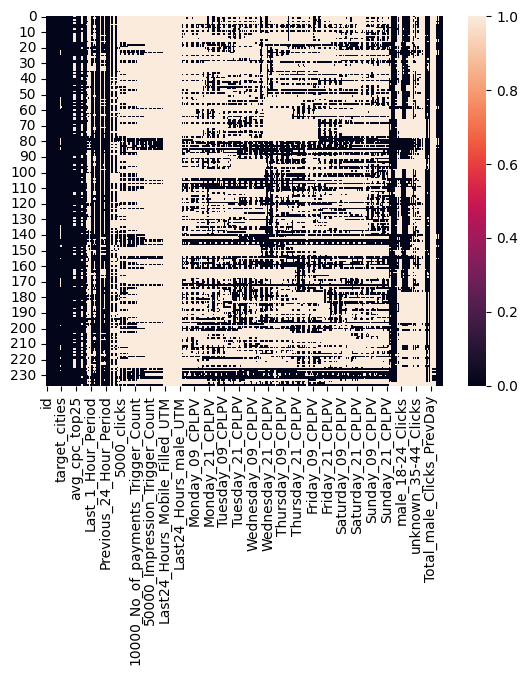

In [91]:
try:
    sns.heatmap(df.isnull())
    # now we can see we clear our most of the data some column remains because data is not accurate and rows
    # very less as well as i cant use dropna because all data will collapse
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

# **Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

In [92]:
df.columns

Index(['id', 'ad_id', 'ad_name', 'clean_ad_name', 'adset_id', 'adset_name',
       'campaign_id', 'campaign_name', 'basis_targeting', 'basis_objective',
       ...
       'ad_type', 'ad_link', 'Link_Urls', 'instagram_permalink_url', 'Reach',
       'Frequency', 'target_advantage_audience', 'Bucket', 'CPLPV',
       'ad_status_of_hourly_table'],
      dtype='object', length=644)

## 1. Average spend by ads platform

In [93]:
try:
    # Average spend by ads platform using the reconstructed column
    avg_spend_by_ads_platform = df.groupby('Ads Platform')['spend'].mean()

    # Plot
    plt.bar(avg_spend_by_ads_platform.index, avg_spend_by_ads_platform.values, color='skyblue')
    plt.xlabel('Ads Platform')
    plt.ylabel('Average Spend')
    plt.title('Average Spend by Ads Platform day wise')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: 'Ads Platform'


##Insights :

* we are spending most approx 2200 in facebook on day to day basis then followed by instagram approx 1600 then on threads approx 1000 rupees
* facebook and instagram spend is higher and threads has least spend half of facebook

## 2. Average Conversion Rate by Ads Platform

In [94]:
try:
    # Create a new column with conversion rate in percentage
    # but i can use inbuilt column to which already i created in data set
    df['Conversion_Rate (%)'] = (df['no_of_payments'] / df['clicks']) * 100
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

In [95]:
try:
    # Grouped conversion rate for ads_platform using the reconstructed column
    conversion_rate_by_platform = df.groupby('Ads Platform')['Conversion_Rate (%)'].mean()
    plt.bar(conversion_rate_by_platform.index, conversion_rate_by_platform.values, color='skyblue')
    plt.title('Average Conversion Rate by Ads Platform')
    plt.ylabel('Conversion Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: 'Ads Platform'


##Insights :

* as in previous bar chart facebook and instagram spend is higher and threads has least spend half of facebook
* although because of less rows and incomplete data set conversion rate is very less still instagram showing good conversion rate 2.5 x of both fb and threads
* as in fb we spend the most still conversion rate even not half of instagram and less than  threds too so we should either improve ad strategy or should spend less in facebook instead must **allocate more budget** on instagram and thread
* thread we spend very less half of fb still its greater than  fb in conversion so can focus more on thread instead of fb

## last 7 days insights : -
* Average Conversion Rate of last 7 days by Ads Platform

In [96]:
try:
    # Grouped conversion rate of last 7 days for ads_platform using the reconstructed column
    conversion_rate_by_platform = df.groupby('Ads Platform')['Last_7_Days_No_of_payments'].mean() # Safely using available numeric column
    plt.bar(conversion_rate_by_platform.index, conversion_rate_by_platform.values, color='skyblue')
    plt.title('Average Payments of last 7 days by Ads Platform')
    plt.ylabel('Avg Payments')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: 'Ads Platform'


##Insights :

* in last 7 days instagram performing good and threads in less spend showing good kpi so we should more focus on these two platform (instagram,thread)

# 3. using bar plot to find outliers of impression (outlier impacting analysis)

## USECASE : -
* i used bar plot below because when i tried to find insight by impression click and how much spending i got an range error in impression which is becasue my data set is small so outlier affecting my data for now i just managed with 90 percentile did not drop that columns

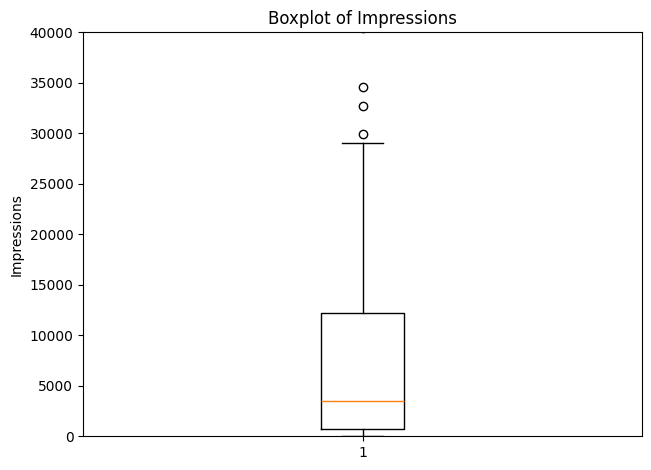

In [97]:
try:
    plt.boxplot(df['impressions'])
    plt.title("Boxplot of Impressions")
    plt.ylabel("Impressions")
    plt.tight_layout()
    plt.ylim(0,40000)
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* MEADIAN ie 50% of the impression are less than 3000 and 75% of the impression are below 13000 and 90-95% of impression below 29000 so rest all impression are outliers which is tempering the data set
* i used ylim 40000 so that we can get accurate box plot but rest outlier can be tackled by lim or percentile of data we will use impression column with 90-95% percentile so that can find accurate insight

## 4. "Relationship Between Clicks and Impressions After Outlier Removal (Hue: Spend)"

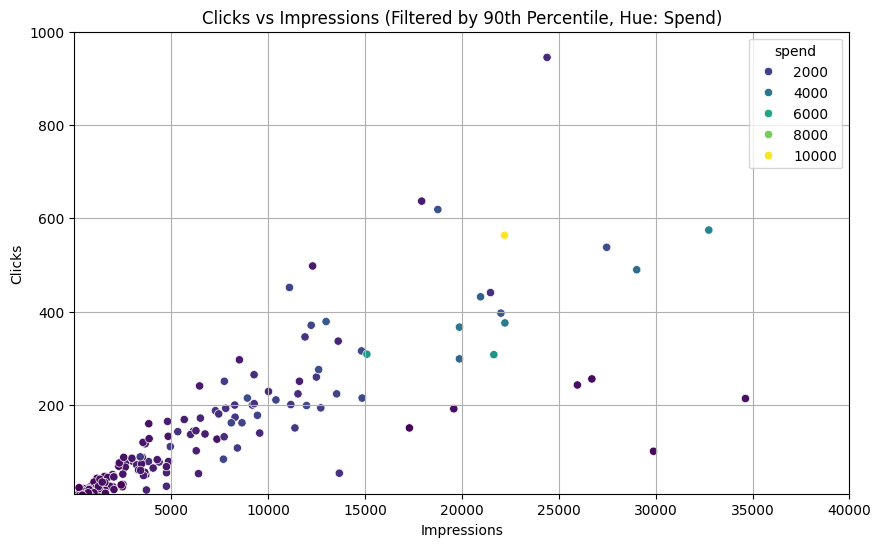

In [98]:
try:
    # Filter data to exclude top 10% of impressions (outliers)
    q90 = df['impressions'].quantile(0.90)
    filtered_df = df[df['impressions'] <= q90]  #here i am selecting data frame all columns but only those rows with 90% temporarily filter_df

    # Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='impressions', y='clicks', hue='spend', palette='viridis')
    plt.title("Clicks vs Impressions (Filtered by 90th Percentile, Hue: Spend)")
    plt.xlabel("Impressions")
    plt.ylabel("Clicks")
    plt.xlim(10,40000)
    plt.ylim(10,1000)
    plt.grid(True)
    plt.show()

    #  permanently removes outliers
    # df = df[df['impressions'] <= df['impressions'].quantile(0.95)]

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :

* i used 90 percentile of impression to remove outliers but this data is not proper accurate so still i need to use ylim, xlim so that find good insights by scatter plot
* as impression increasing clicks also increasing mostly impression volume under 5000 and clicks are about 1-170 approx and spend  2000 ie in our ads data set mostly impression in 5k category and cliks under 170
* from 5k - 15k impression clicks are from 100 - 400 and spend also less amount like 2k 4k which is good
* so we have to focus more on below 15k impression and 2k-4k spend getting good cliks and most of impression range in budget

* **REMARK** : - but if my impression 5-10k still MAJOR clicks below 200 which is good at 5k impressions too it mean here leverage impression may be impacting qulity cutomer like age group increase or area increase so why pay 4000 if we focus on quality impression then even good output at 2000

## 5. No. of Payments by Gender

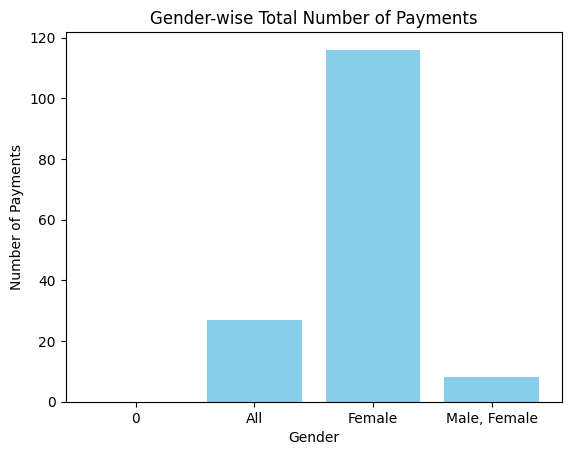

In [99]:
try:
    # Grouping the data with no of payments and gender
    gender_payments = df.groupby("target_genders")["no_of_payments"].sum()
    plt.bar(gender_payments.index, gender_payments.values, color='skyblue')
    plt.title("Gender-wise Total Number of Payments")
    plt.ylabel("Number of Payments")
    plt.xlabel("Gender")
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* our product loved by female gender more than a man while 115 no of payments by female male did only 35 no of payments 1/4th ie we can focus more on female and can do experiment why man not liking and can attract man consumers too

## 5.1 **advance grouping to find out sum of number of payments with genders and ads platform**

In [100]:
try:
    # Group and reshape using reconstructed column
    grouped = df.groupby(['target_genders', 'Ads Platform'])['no_of_payments'].sum().unstack()

    # Plot
    colors = ['#1f77b4', '#ff7f0e']  # We currently have Facebook and Instagram
    grouped.plot(kind='bar', figsize=(10, 6), color=colors)
    plt.title("No. of Payments by Gender and Ads Platform")
    plt.ylabel("No. of Payments")
    plt.xlabel("Gender")
    plt.legend(title="Ads Platform")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to missing column: 'Ads Platform'


In [101]:
# Reconstruct the 'Ads Platform' column by extracting the platform from 'adset_name'
def extract_platform(adset):
    adset_lower = str(adset).lower()
    if 'insta' in adset_lower or 'instagram' in adset_lower:
        return 'Instagram'
    elif 'thread' in adset_lower:
        return 'Thread'
    else:
        # Defaulting to Facebook as the primary alternative platform mentioned in project overview
        return 'Facebook'

df['Ads Platform'] = df['adset_name'].apply(extract_platform)
data['Ads Platform'] = data['adset_name'].apply(extract_platform)

# Let's verify the distribution of the newly created column
print("Ads Platform Distribution:")
print(df['Ads Platform'].value_counts())

Ads Platform Distribution:
Ads Platform
Facebook     136
Instagram    101
Name: count, dtype: int64


##Insights :

* we know female are 4x more odering than man but in this now we can find out which platform they using most
* females favourite platform is instagram in top then facebook so we can do gender specific ads run these two
* males are using instagram and thread not fb so we can run insta thraed for both gender but fb only to female

In [102]:
# Extract month from the ad_start_date column to avoid KeyError
data['START_month'] = pd.to_datetime(data['ad_start_date']).dt.strftime('%B')

# TRENDS INSIGHTS WITH DATE DAY HOUR MONTH

## 6. 1. Daily CPC Trend Over Time

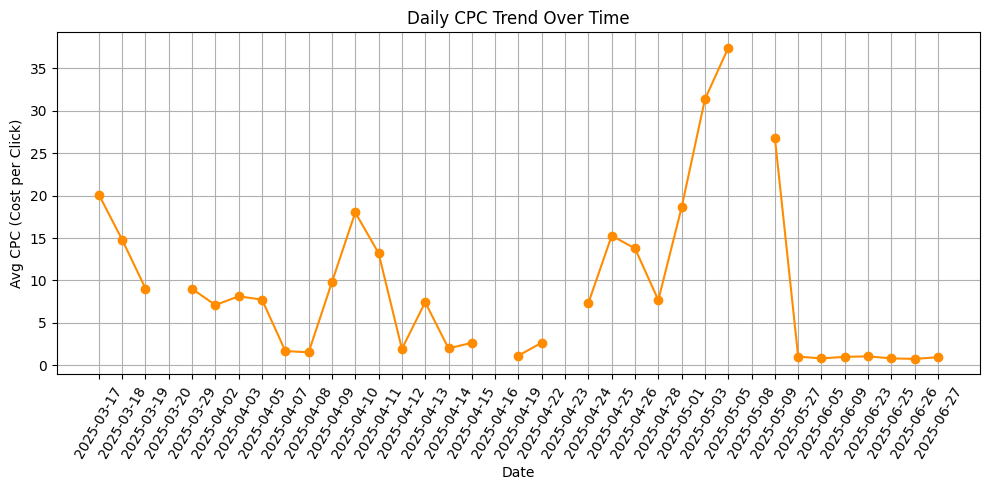

In [103]:
# Ensure datetime format
df['ad_start_date'] = pd.to_datetime(df['ad_start_date'])

# Create START_date column with YYYY-MM-DD
df['START_date'] = df['ad_start_date'].dt.date.astype(str)

# Group by date and calculate average CPC (using correct column 'cpc')
daily_cpc = df.groupby('START_date')['cpc'].mean().reset_index()

# Plot line chart
plt.figure(figsize=(10, 5))
plt.plot(daily_cpc['START_date'], daily_cpc['cpc'], marker='o', color='darkorange')

plt.title('Daily CPC Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Avg CPC (Cost per Click)')
plt.xticks(rotation=60)
plt.grid(True)
plt.tight_layout()
plt.show()

##Insights :
* major percentage cost per clicks are below 15
* 11 april to 22 april cpc below 5 so here we could use benifit of that by running more ads
* similarly 9 may to till 27 june cpc is flat at 2-3 its good opportunity to invest more on ads will  cost cheaper

## 6.2. **Hourly Click**  trend over time

/tmp/ipykernel_1010/177135619.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


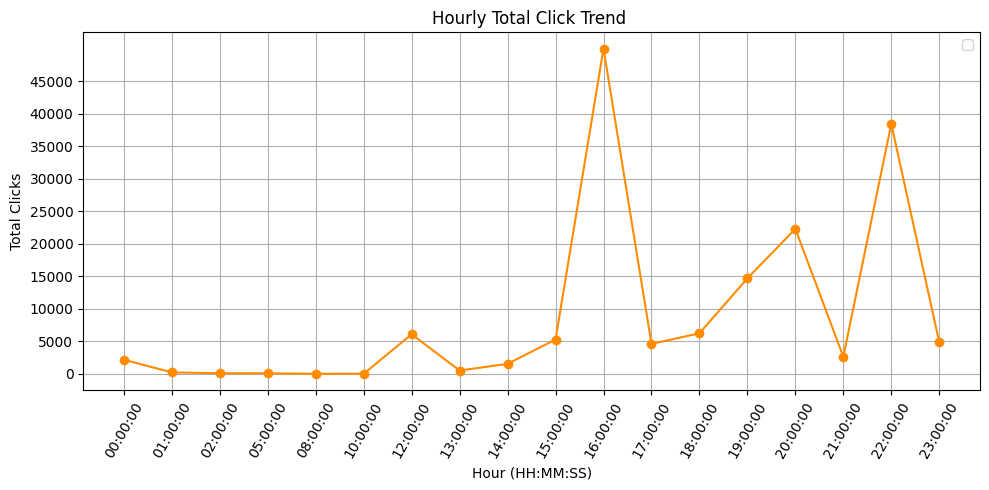

In [104]:
try:
    df['START_date'] = df['ad_start_date'].dt.time.astype(str)

    # Group by full date and calculate total CPC
    hourly_cpc = df.groupby('START_date')['clicks'].sum().reset_index()

    # Plot line chart
    plt.figure(figsize=(10, 5))
    plt.plot(hourly_cpc['START_date'], hourly_cpc['clicks'], marker='o', color='darkorange')
    plt.title('Hourly Total Click Trend ')
    plt.xlabel('Hour (HH:MM:SS)')
    plt.ylabel('Total Clicks')
    plt.xticks(rotation=60)
    plt.yticks(np.arange(0, 50000, 5000))  #zoom in out
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* 3pm to till approx 4:30 pm sum of clicks in all days data is at peak arround 50 k similarly 9pm to 11 pm has good traffic and clicks arround overall 35000
so we can target these houe more and from 12am to 10pm cliks are very less because of midnight so we can try to not show ads in this time duration

### 6.3. monthly cpc trend over time

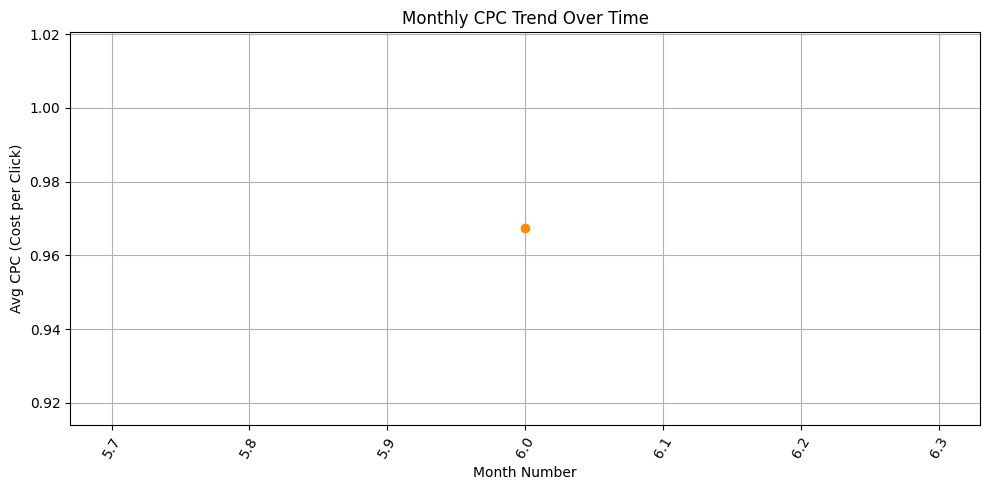

In [105]:
try:
    df['START_date'] = df['ad_start_date'].dt.month

    # Group by month and calculate average CPC using the correct column 'cpc'
    monthly_cpc = df.groupby('START_date')['cpc'].mean().reset_index()

    # Plot line chart
    plt.figure(figsize=(10, 5))
    plt.plot(monthly_cpc['START_date'], monthly_cpc['cpc'], marker='o', color='darkorange')

    plt.title('Monthly CPC Trend Over Time')
    plt.xlabel('Month Number')
    plt.ylabel('Avg CPC (Cost per Click)')
    plt.xticks(rotation=60)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
march to mid may avg cost per clicks were between 10-20 which is making us to run more costly ads in june major drop in avg cpc so can run more ads with cheaper values

## 7. Top 10 / all Best Performing Campaigns by Total no of  Payments

In [106]:
try:
    # Identify the most popular campaign_name
    #Since .value_counts() returns the campaign_name sorted by frequency in descending order (from most to least frequent), .head(10)
    top_campaign_name = df['campaign_name'].value_counts().head(10)
    print("The most popular campaign_name:")
    print(top_campaign_name)
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

The most popular campaign_name:
campaign_name
Web App | Conversion | StepOut | Delhi | Faridabad | Noida - VM    177
VM_RMK                                                              24
VM || Delhi NCR  || Traffic || 16-05-2025                           16
Instagram post: Our latest StepOut dinner was...                     2
Instagram post: Dinner with strangers? Feels...                      2
Instagram post: Gurgaon, we’ve stepped in ??\nYour...                2
VM || Delhi NCR || Brand Awareness || 16-05-2025                     2
Instagram post: We could hype it up. But they...                     2
1 | TOF Engagement Campaign | 21 Feb 2025                            1
Instagram post: “Why dinner with strangers?”...                      1
Name: count, dtype: int64


/tmp/ipykernel_1010/954932309.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_campaigns.values, y=top_campaigns.index, palette='crest')


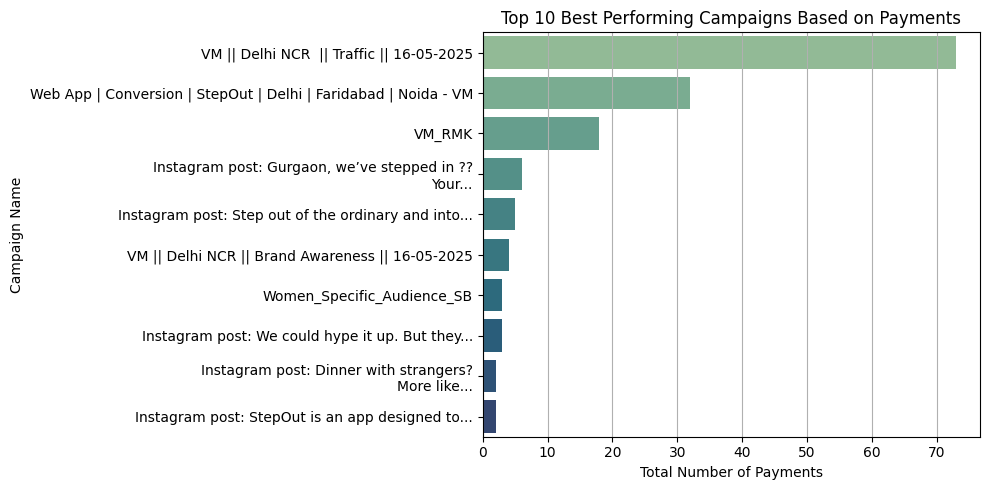

In [107]:
try:
    # Top 10 Best Performing Campaigns by Total no of  Payments
    top_campaigns = df.groupby('campaign_name')['no_of_payments'].sum().sort_values(ascending=False).head(10)

    #all for which shall we stop
    #top_campaigns = df.groupby('campaign_name')['no_of_payments'].sum().sort_values(ascending=False)

    # Plotting
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_campaigns.values, y=top_campaigns.index, palette='crest')
    plt.xlabel('Total Number of Payments')
    plt.ylabel('Campaign Name')
    plt.title('Top 10 Best Performing Campaigns Based on Payments')
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* from all compaign top 5 compaign performing well so we can allocate budgets accordingly and can find casue why other compaign not doing well so Budget allocation should be rebalanced toward these high-performing campaigns
* vm traffic is top compaign then web app then vm rmk and instagram post so we can focus more on this and can give less preference others
Focus efforts on scaling them further

## 8. Engagement Rate [CTR] by Age Group

In [108]:
try:
    #avg_ctr = df.groupby('target_age_range')['ctr_Engagement_rate'].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data = df , x= 'target_age_range', y='ctr_Engagement_rate', hue='target_age_range', palette='coolwarm')
    plt.xlabel('Target Age Range')
    plt.ylabel('Engagement Rate (%) [CTR]')
    plt.title('Engagement Rate [CTR] by Age Group')
    plt.grid(True)
    plt.show()

except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

Skipping cell due to error: Could not interpret value `ctr_Engagement_rate` for `y`. An entry with this name does not appear in `data`.


<Figure size 800x500 with 0 Axes>

##Insights :
* 40-44 age range giving best ctr ie click/impressions so generally can say 35-44 age group giving good ctr
* in general from this data we can rum ads from 18-45 years so that here we are covering our all cutomers but maily 35-44 and 18-29 more efficient

## 9. Pie Chart for target_regions

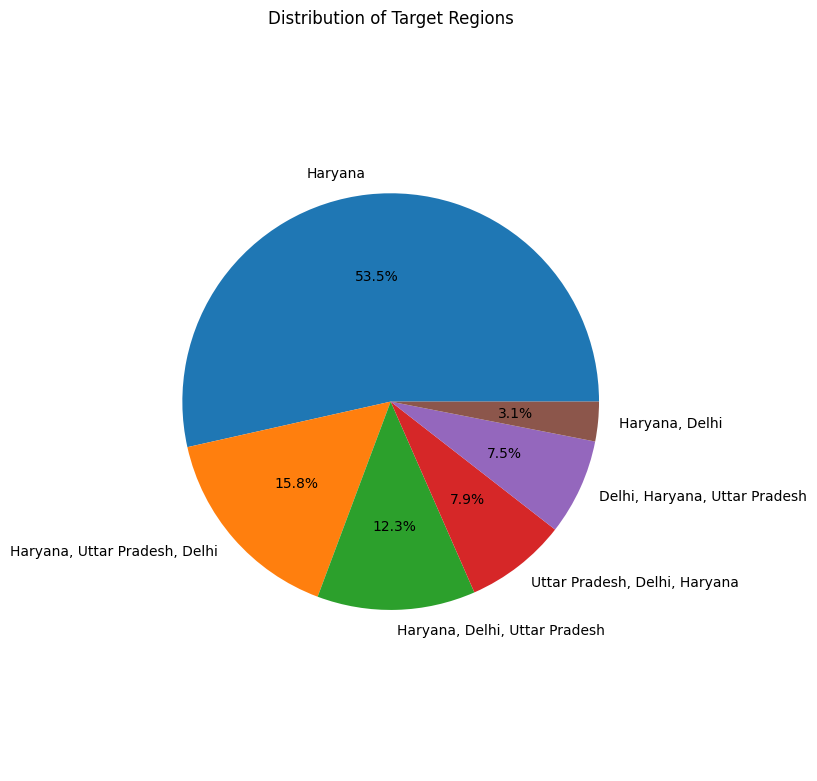

In [109]:
try:
    # Count of each region
    region_counts = df['target_regions'].value_counts().head(6)
    plt.figure(figsize=(8, 8))
    plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
    plt.title('Distribution of Target Regions')
    plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* 53.5% contibution only by haryana because of gurugram so we can more allocate our budget to haryana region
* haryana delhi up has 28% so we need to allocate more budget in ncr regions for now
* as i used head 6 so rest region giving very less even not 1-2% contibution so we can ignore or do no allocate budget for that

## 10. Pie Chart for target_cities

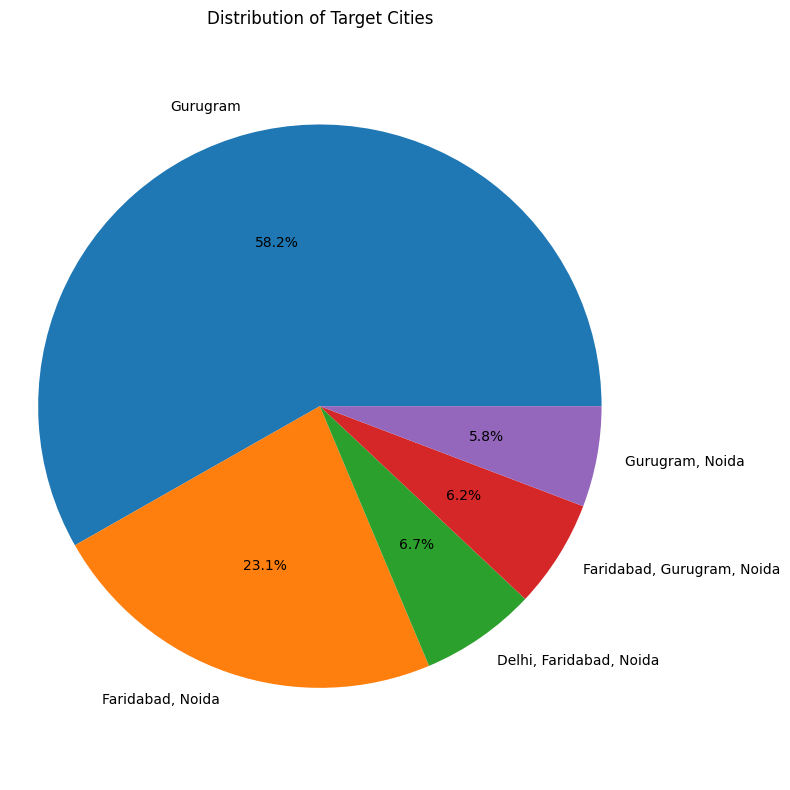

In [110]:
try:
    # Count of each region
    cities_counts = df['target_cities'].value_counts().head(5)
    plt.figure(figsize=(8, 8))
    plt.pie(cities_counts, labels=cities_counts.index, autopct='%1.1f%%')
    plt.title('Distribution of Target Cities')
    plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f"Skipping cell due to missing column: {e}")
except Exception as e:
    print(f"Skipping cell due to error: {e}")

##Insights :
* if i draw a pie chart with all target cities so 0.8% unknown data 1.7% delhi etc data 2.5 % gaziabad and etc data which is overall approx 5% so we can focus on 95% by head 5
*  **High Concentration in NCR Cities** : - most target we are achieeving in gurugram and faridabad noida approx 80% of 100 % so we can focus more in these cities aswell as some other like 6.7% delhi fridabad where we can explore but rest residuls for now we can ignore or find new ad strategy

###THANK YOU